# 03 PINN Experiments

???????? PINN ? ablation: ???? loss ? ??????? ????.

In [2]:
import numpy as np
import torch
from torch import optim
from src.modeling import PINN, LossWeights, pinn_loss, train_model, save_model_weights
from src.utils import plot_loss_curves

In [3]:
data = np.load('data/processed/pinn_dataset.npz')
collocation = torch.tensor(data['collocation_norm'], dtype=torch.float32)
ic = torch.tensor(data['initial_norm'], dtype=torch.float32)
bc = {
    'left': torch.tensor(data['boundary_left_norm'], dtype=torch.float32),
    'right': torch.tensor(data['boundary_right_norm'], dtype=torch.float32),
    'top': torch.tensor(data['boundary_top_norm'], dtype=torch.float32),
    'bottom': torch.tensor(data['boundary_bottom_norm'], dtype=torch.float32),
}

In [4]:
def train_one(num_hidden_layers=5, lambda_bc=1000.0, lambda_ic=100.0, epochs=1200):
    model = PINN(input_dim=3, hidden_dim=60, num_hidden_layers=num_hidden_layers)
    weights = LossWeights(lambda_pde=1.0, lambda_bc=lambda_bc, lambda_ic=lambda_ic)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    def loss_fn():
        out = pinn_loss(model, collocation, bc, ic, weights=weights, alpha=0.05)
        return out['total']

    history = train_model(model, loss_fn, opt, epochs=epochs, log_every=300)
    return model, history

[  300] loss=3.883977e+01
[  600] loss=3.878437e+01
[  900] loss=3.749666e+01
[ 1200] loss=3.550449e+01


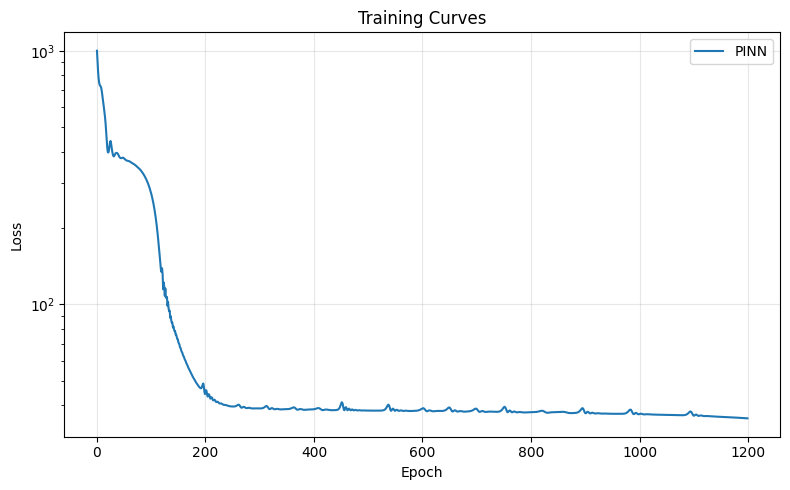

In [5]:
model, history = train_one()
plot_loss_curves([history], ['PINN'])

In [6]:
weights_path = save_model_weights(model, 'models/pinn_main.pt')
print('saved:', weights_path)


saved: models\pinn_main.pt


In [7]:
ablation_configs = [
    {'num_hidden_layers': 3, 'lambda_bc': 500.0, 'lambda_ic': 50.0},
    {'num_hidden_layers': 5, 'lambda_bc': 1000.0, 'lambda_ic': 100.0},
    {'num_hidden_layers': 7, 'lambda_bc': 1500.0, 'lambda_ic': 200.0},
]
results = []
for cfg in ablation_configs:
    _, h = train_one(**cfg, epochs=600)
    results.append({**cfg, 'final_loss': float(h[-1])})

results

[  300] loss=3.481991e+01
[  600] loss=2.121561e+01
[  300] loss=4.094729e+01
[  600] loss=3.909167e+01
[  300] loss=5.482022e+01
[  600] loss=5.436207e+01


[{'num_hidden_layers': 3,
  'lambda_bc': 500.0,
  'lambda_ic': 50.0,
  'final_loss': 21.215612411499023},
 {'num_hidden_layers': 5,
  'lambda_bc': 1000.0,
  'lambda_ic': 100.0,
  'final_loss': 39.09166717529297},
 {'num_hidden_layers': 7,
  'lambda_bc': 1500.0,
  'lambda_ic': 200.0,
  'final_loss': 54.36206817626953}]